# **PARTE 1: Carga de Datos**

In [1]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Mostrar dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


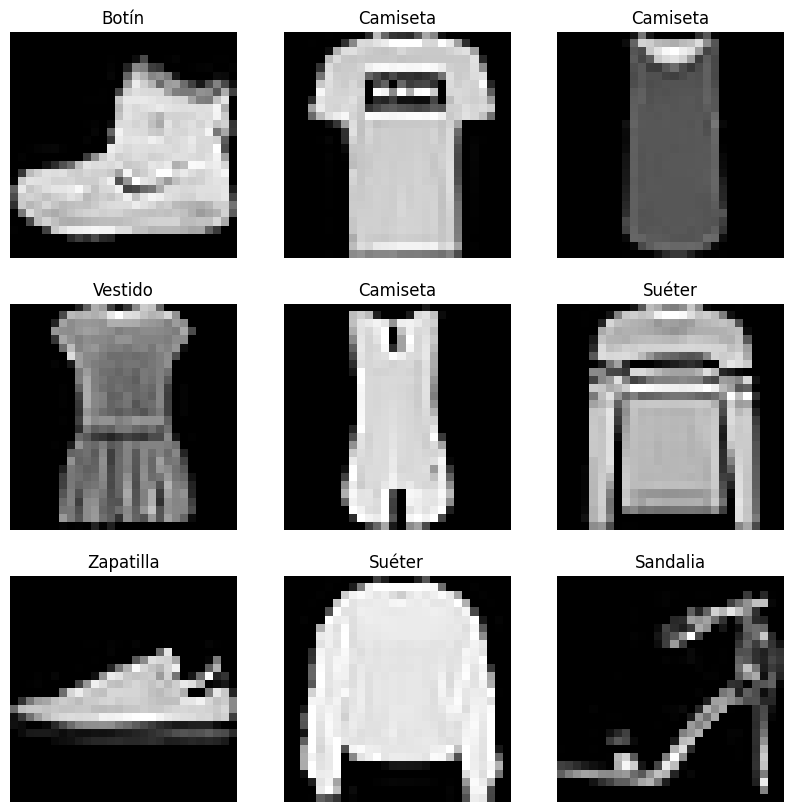

In [2]:
# Nombres de clases
clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Mostrar ejemplos
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.show()

Se utilizó el dataset Fashion-MNIST disponible en Keras, el cual contiene imágenes en escala de grises de 28x28 píxeles correspondientes a distintas categorías de prendas de vestir.

El conjunto de datos está dividido en 60.000 imágenes para entrenamiento y 10.000 para prueba. Cada imagen está etiquetada en una de las 10 clases disponibles, como camisetas, pantalones, zapatos, entre otros.

Se visualizaron algunos ejemplos del dataset para comprender la estructura de los datos y las clases asociadas.



---
---


# **PARTE 2: Preprocesamiento de Datos**

In [3]:
# Normalizar los datos (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar las imágenes (28x28 → 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# One-hot encoding de las etiquetas
Y_train = keras.utils.to_categorical(y_train, 10)
Y_test = keras.utils.to_categorical(y_test, 10)

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (60000, 784)
Y_train: (60000, 10)


Para preparar los datos para el entrenamiento de la red neuronal, se realizaron varias transformaciones.

Primero, se normalizaron los valores de los píxeles dividiéndolos por 255, con el objetivo de llevarlos a un rango entre 0 y 1. Esto mejora la estabilidad del entrenamiento y permite una mejor convergencia del modelo.

Luego, las imágenes de 28x28 píxeles fueron transformadas a vectores unidimensionales de 784 elementos, ya que las redes MLP requieren entradas en formato vectorial.

Finalmente, las etiquetas fueron convertidas a formato one-hot encoding, lo que permite representar cada clase como un vector binario, facilitando el uso de la función de pérdida para clasificación multiclase.



---

---

# **PARTE 3: Modelo MLP**

In [4]:
# setamos los seed para números random:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos las dimensiones de entrada y salida
N = X_train.shape[1]  # Dimensiones de entrada (784 píxeles)
C = Y_train.shape[1]  # Número de clases de salida (10 clases)

# Creación de la red:

h1 = 512
h2 = 256

model = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N,  activation='relu'),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dense(C, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

El modelo implementado corresponde a una red neuronal multicapa (MLP) compuesta por tres capas ocultas con 512, 256 y 256 neuronas respectivamente, y una capa de salida de 10 neuronas.

El modelo presenta un total de 601.610 parámetros entrenables, lo que indica una alta capacidad de aprendizaje. Esta gran cantidad de parámetros permite al modelo capturar patrones complejos presentes en las imágenes del dataset.

Sin embargo, esta alta capacidad también implica un mayor riesgo de sobreajuste, ya que el modelo puede llegar a memorizar los datos de entrenamiento en lugar de generalizar correctamente.

Por esta razón, este modelo será utilizado como base para posteriormente aplicar técnicas de regularización que permitan mejorar su desempeño en datos no vistos.


---
---


# **PARTE 4: Entrenamiento y Visualización**

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8222 - loss: 0.4922 - val_accuracy: 0.8554 - val_loss: 0.4079
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8621 - loss: 0.3723 - val_accuracy: 0.8679 - val_loss: 0.3634
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8769 - loss: 0.3311 - val_accuracy: 0.8768 - val_loss: 0.3393
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8848 - loss: 0.3072 - val_accuracy: 0.8778 - val_loss: 0.3455
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8929 - loss: 0.2861 - val_accuracy: 0.8801 - val_loss: 0.3349
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8990 - loss: 0.2681 - val_accuracy: 0.8833 - val_loss: 0.3318
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9031 - loss: 0.2557 - val_accuracy: 0.8868 - val_loss: 0.3334
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9078 -



> El modelo fue entrenado durante 30 épocas utilizando un tamaño de batch de 32 y reservando un 20% de los datos para próxima validación.





In [ ]:
# Visualización de resultados:

print(f"Train accuracy \u2248 {history.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history.history['val_accuracy'][-1]*100:.1f}%")

# **4.1: Visualización:**

# Gráfico de Loss y Accuracy:

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()



> **Accuracy de Entrenamiento (azul):** Se observa una mejora constante en la precisión del modelo en el conjunto de entrenamiento, alcanzando valores superiores al 93% al final del entrenamiento. Esto indica que el modelo está aprendiendo bien los patrones de los datos que ha visto.


> **Accuracy de Validación (naranja):** La precisión en el conjunto de validación también mejora inicialmente, pero tiende a estabilizarse o incluso a fluctuar ligeramente alrededor del 88-89% después de un cierto número de épocas (aproximadamente a partir de la época 8-10). La brecha creciente entre la precisión de entrenamiento y la de validación sugiere que el modelo podría estar comenzando a sobreajustarse (overfitting) a los datos de entrenamiento, lo que significa que no generaliza tan bien a datos nuevos y no vistos.


> **Loss de Entrenamiento (azul):** La pérdida en el conjunto de entrenamiento disminuye de manera constante a lo largo de todas las épocas, lo que es una señal positiva de que el modelo está aprendiendo y reduciendo su error en los datos de entrenamiento.


> **Loss de Validación (naranja):** La pérdida en el conjunto de validación disminuye al principio, pero luego comienza a aumentar o a fluctuar al alza, mientras que la pérdida de entrenamiento sigue disminuyendo. Esta divergencia es un claro indicador de sobreajuste. El modelo está memorizando los datos de entrenamiento, lo que le permite reducir su pérdida en ellos, pero esta memorización no se traduce en un mejor rendimiento en los datos de validación, sino en un empeoramiento o estancamiento.





# **Conclusión:**

Los gráficos sugieren que el modelo se está sobreajustando. Aunque el modelo aprende muy bien los datos de entrenamiento, su capacidad para generalizar a nuevos datos (validación) comienza a deteriorarse después de las primeras épocas.


 Para mejorar el modelo, se aplicarán estas dos técnicas:


> **Dropout:** añadir capas de regularización para evitar que el modelo reajuste demasiado los datos de entrenamiento.

> **Early Stopping:** detención temprana para finalizar entrenamiento cuando la pérdida validación comience a subir.






---



---



# **PARTE 5: Comparación de optimizadores**



En esta parte, se evaluarán cómo distintos optimizadores afectan el aprendizaje del modelo MLP.

Se probaran:

- **SGD**.

- **Adam**.

- **RMSprop**.


In [ ]:
histories = {}

optimizadores = ['sgd', 'adam', 'rmsprop']

for opt in optimizadores:

    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        # X_train[:20000], Y_train[:20000],
        X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    histories[opt] = history

In [ ]:
plt.figure(figsize=(8,6))

for opt in histories:
    plt.plot(histories[opt].history['val_accuracy'], marker='o', label=opt)

plt.title("Comparación de optimizadores")
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
mejor_opt = df_opt.sort_values(by="Mejor Val Accuracy", ascending=False).iloc[0]["Optimizador"]

print("Mejor optimizador:", mejor_opt)

# **PARTE 6: Regularización**


**6.1. Regularización con Dropout:**

In [ ]:
# Setamos los seed para números random

np.random.seed(30)
tf.random.set_seed(30)

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(C, activation='softmax'))

model_dropout.summary()

model_dropout.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(X_train, Y_train,
        epochs=30,
        batch_size=32,
        validation_data=(X_test,Y_test)
       )

In [ ]:
print(f"Train accuracy \u2248 {history_dropout.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_dropout.history['val_accuracy'][-1]*100:.1f}%")

In [ ]:
plt.plot(history_dropout.history['loss'], label='Train')
plt.plot(history_dropout.history['val_loss'], label='Test')
plt.title('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(history_dropout.history['accuracy'], label='Train')
plt.plot(history_dropout.history['val_accuracy'], label='Test')
plt.title('% Acierto')
plt.xlabel('Época')
plt.legend()
plt.show()



---



**6.2. Regularización con EarlyStopping**